## Algorithm 

Stage 1: Offline Calibration
    1A. Camera calibration
    1B. Dodecahedron calibration (bundle adjustment)
    1C. Pen-tip calibration

Stage 2: Online Tracking (per frame)
    2A. Approximate Pose Estimation (APE)
    2B. Inter-frame Corner Tracking (ICT) if needed
    2C. Dense Pose Refinement (DPR)
    2D. Pen-tip world computation

Stage 3: Drawing Logic
    3A. Detect contact
    3B. Record trajectory

## Pseudocode: Dodecahedron Calibration
INPUT:
    images_calib[]
    initial_marker_poses[]
    camera_intrinsics

VARIABLES:
    marker_pose[j]
    object_pose[k]

FIX:
    marker_pose[0]  // to avoid gauge freedom

INITIALIZE:
    marker_pose[j] ← ideal CAD positions
    object_pose[k] ← APE result

REPEAT until convergence:
    FOR each image k:
        FOR each visible marker j:
            project model points
            compute intensity residual

    build Jacobian wrt:
        marker_pose[j]
        object_pose[k]

    solve normal equations using Gauss-Newton
    update parameters

Output:

refined_marker_poses


Pen-Tip Calibration

We assume pen tip is fixed in world.

Equation:


Rkc+tk =Rlc+tl
	​
Solve linear least squares.

Pseudocode: Pen Tip Calibration
INPUT:
    multiple tracked poses (R_k, t_k)

Build linear system:
    (R_k - R_l) c = (t_l - t_k)

Stack all equations
Solve using least squares

OUTPUT:
    pen_tip_position c (object frame)

## Pseudocode: APE
function APE(frame):

    markers = detect_aruco(frame)

    if number_of_markers >= 2:
        corners_2d = extract_corners(markers)
        points_3d = corresponding_model_points()

        pose = solve_PnP(points_3d, corners_2d)

        return pose, SUCCESS
    else:
        return None, FAIL


## Pseudocode: ICT
function ICT(prev_frame, curr_frame, prev_corners):

    tracked_corners = LK_optical_flow(prev_frame, curr_frame, prev_corners)

    reject_outliers_by_velocity(tracked_corners)

    if enough_corners:
        pose = solve_PnP(model_points, tracked_corners)
        return pose, SUCCESS
    else:
        return None, FAIL

## Pseudocode: Dense Pose Refinement
function DPR(frame, pose_initial):

    p ← pose_initial

    FOR iter = 1 to max_iter:

        project model points using p

        sample image intensities
        sample model intensities (mipmap)

        compute residual r = I_model - I_image

        compute Jacobian J wrt pose

        solve:
            Δp = (JᵀJ)^(-1) Jᵀ r

        # Backtracking line search
        α = 1
        WHILE E(p + αΔp) > Armijo_condition:
            α = 0.5 * α

        p ← p + αΔp

        if ||Δp|| small:
            break

    return p

function compute_pen_tip(pose, c_object):

    R, t = pose
    c_world = R @ c_object + t

    return c_world

distance = dot(plane_normal, c_world - plane_origin)

if distance < pen_ball_radius:
    drawing = True
else:
    drawing = False

In [1]:
import pyrealsense2 as rs
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

## Aruco Markers Generation

In [ ]:
# -----------------------------
# Parameters
# -----------------------------
dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)

marker_size_pixels = 600  # resolution of image
num_markers = 12          # for 12 faces of dodecahedron

output_folder = r"E:\Sanjay\aruco_markers"
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# Generate Markers
# -----------------------------
for marker_id in range(num_markers):
    marker_img = cv2.aruco.generateImageMarker(
        dictionary,
        marker_id,
        marker_size_pixels
    )

    filename = f"{output_folder}/marker_{marker_id}.png"
    cv2.imwrite(filename, marker_img)

print("Markers generated successfully.")

Markers generated successfully.


## CheckerBoard Generation

In [ ]:
# Create a 10x7 grid (for 9x6 corners)
board = np.zeros((700, 1000), dtype=np.uint8)  # Height 700px (7*100), Width 1000px (10*100)
for i in range(7):  # Rows
    for j in range(10):  # Columns
        if (i + j) % 2 == 0:
            board[i*100:(i+1)*100, j*100:(j+1)*100] = 255  # White squares
cv2.imwrite('chessboard_10x7.png', board)

True

In [18]:
import numpy as np
import cv2

# -----------------------------
# Parameters
# -----------------------------
square_size_mm = 35
dpi = 300
num_cols = 10   # squares
num_rows = 7    # squares

# -----------------------------
# Convert mm to pixels
# -----------------------------
square_size_px = int((square_size_mm / 25.4) * dpi)

width_px = num_cols * square_size_px
height_px = num_rows * square_size_px

# -----------------------------
# Create checkerboard
# -----------------------------
board = np.zeros((height_px, width_px), dtype=np.uint8)

for i in range(num_rows):
    for j in range(num_cols):
        if (i + j) % 2 == 0:
            board[
                i*square_size_px:(i+1)*square_size_px,
                j*square_size_px:(j+1)*square_size_px
            ] = 255

# -----------------------------
# Save image with DPI metadata
# -----------------------------
cv2.imwrite("checkerboard_35mm_300dpi.png", board)

print("Saved checkerboard_35mm_300dpi.png")
print("Square size (pixels):", square_size_px)
print("Image size:", width_px, "x", height_px)


Saved checkerboard_35mm_300dpi.png
Square size (pixels): 413
Image size: 4130 x 2891


## Checkerboard data collection

In [6]:
# Create output folder if it doesn't exist
output_folder = 'calib_images'
os.makedirs(output_folder, exist_ok=True)

# Configure RealSense pipeline for RGB stream
pipeline = rs.pipeline()
config = rs.config()
config.enable_stream(rs.stream.color, 1280,720, rs.format.bgr8, 30)  # RGB at 640x480, 30 FPS (adjust resolution if needed)

# Start streaming
pipeline.start(config)

image_count = 0
try:
    while True:
        # Wait for a coherent pair of frames: depth and color (but we only need color)
        frames = pipeline.wait_for_frames()
        color_frame = frames.get_color_frame()
        if not color_frame:
            continue

        # Convert to numpy array (BGR format for OpenCV)
        color_image = np.asanyarray(color_frame.get_data())

        # Display the image
        cv2.imshow('RealSense RGB Capture', color_image)

        # Key controls
        key = cv2.waitKey(1) & 0xFF
        if key == ord('s'):  # Press 's' to save the image
            filename = os.path.join(output_folder, f'calib_image_{image_count:03d}.jpg')
            cv2.imwrite(filename, color_image)
            print(f'Saved: {filename}')
            image_count += 1
        elif key == ord('q'):  # Press 'q' to quit
            break

finally:
    # Stop streaming
    pipeline.stop()
    cv2.destroyAllWindows()

print(f'Total images captured: {image_count}')

Saved: calib_images\calib_image_000.jpg
Saved: calib_images\calib_image_001.jpg
Saved: calib_images\calib_image_002.jpg
Saved: calib_images\calib_image_003.jpg
Saved: calib_images\calib_image_004.jpg
Saved: calib_images\calib_image_005.jpg
Saved: calib_images\calib_image_006.jpg
Saved: calib_images\calib_image_007.jpg
Saved: calib_images\calib_image_008.jpg
Saved: calib_images\calib_image_009.jpg
Saved: calib_images\calib_image_010.jpg
Saved: calib_images\calib_image_011.jpg
Saved: calib_images\calib_image_012.jpg
Saved: calib_images\calib_image_013.jpg
Saved: calib_images\calib_image_014.jpg
Saved: calib_images\calib_image_015.jpg
Saved: calib_images\calib_image_016.jpg
Total images captured: 17


## dodeca dataset collection

In [3]:
save_folder = "dodeca_dataset"
os.makedirs(save_folder, exist_ok=True)

pipeline = rs.pipeline()
config = rs.config()
config.enable_stream(rs.stream.color, 1280, 720, rs.format.bgr8, 30)
pipeline.start(config)

count = 0

print("Press SPACE to save image, ESC to quit")

try:
    while True:
        frames = pipeline.wait_for_frames()
        color_frame = frames.get_color_frame()
        if not color_frame:
            continue

        frame = np.asanyarray(color_frame.get_data())
        cv2.imshow("Capture Dodecahedron", frame)

        key = cv2.waitKey(1)

        if key == 27:
            break
        elif key == 32:
            filename = f"{save_folder}/dodeca_{count}.jpg"
            cv2.imwrite(filename, frame)
            print("Saved:", filename)
            count += 1

finally:
    pipeline.stop()
    cv2.destroyAllWindows()

Press SPACE to save image, ESC to quit
Saved: dodeca_dataset/dodeca_0.jpg
Saved: dodeca_dataset/dodeca_1.jpg
Saved: dodeca_dataset/dodeca_2.jpg
Saved: dodeca_dataset/dodeca_3.jpg
Saved: dodeca_dataset/dodeca_4.jpg
Saved: dodeca_dataset/dodeca_5.jpg
Saved: dodeca_dataset/dodeca_6.jpg
Saved: dodeca_dataset/dodeca_7.jpg
Saved: dodeca_dataset/dodeca_8.jpg
Saved: dodeca_dataset/dodeca_9.jpg
Saved: dodeca_dataset/dodeca_10.jpg
Saved: dodeca_dataset/dodeca_11.jpg
Saved: dodeca_dataset/dodeca_12.jpg
Saved: dodeca_dataset/dodeca_13.jpg
Saved: dodeca_dataset/dodeca_14.jpg
Saved: dodeca_dataset/dodeca_15.jpg
Saved: dodeca_dataset/dodeca_16.jpg
Saved: dodeca_dataset/dodeca_17.jpg
Saved: dodeca_dataset/dodeca_18.jpg
Saved: dodeca_dataset/dodeca_19.jpg
Saved: dodeca_dataset/dodeca_20.jpg
Saved: dodeca_dataset/dodeca_21.jpg
Saved: dodeca_dataset/dodeca_22.jpg
Saved: dodeca_dataset/dodeca_23.jpg
Saved: dodeca_dataset/dodeca_24.jpg
Saved: dodeca_dataset/dodeca_25.jpg
Saved: dodeca_dataset/dodeca_26.jpg

## Camera Calibration

In [7]:
chessboard_size = (9, 6)
square_size = 35  # 2.5 cm if that's your board

objp = np.zeros((chessboard_size[0]*chessboard_size[1],3), np.float32)
objp[:,:2] = np.mgrid[0:chessboard_size[0],0:chessboard_size[1]].T.reshape(-1,2)
objp *= square_size

objpoints = []
imgpoints = []

images = glob.glob('calib_images/*.jpg')

for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCorners(gray, chessboard_size, None)

    if ret:
        objpoints.append(objp)
        imgpoints.append(corners)

ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, gray.shape[::-1], None, None)

print("Camera Matrix:\n", camera_matrix)
print("Distortion:\n", dist_coeffs)
# ... after calibrateCamera ...

print("Reprojection error (RMS):", ret)

# Per-image reprojection error (very useful for debugging)
mean_error = 0
for i in range(len(objpoints)):
    imgpoints2, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], camera_matrix, dist_coeffs)
    error = cv2.norm(imgpoints[i], imgpoints2, cv2.NORM_L2)/len(imgpoints2)
    mean_error += error
    print(f"Image {i}: reproj error = {error:.4f} px")

print("Overall mean reprojection error:", mean_error/len(objpoints))

Camera Matrix:
 [[669.29608432   0.         648.06304662]
 [  0.         670.25267133 374.51993503]
 [  0.           0.           1.        ]]
Distortion:
 [[-0.0890949   0.16490588  0.00123934 -0.00173764 -0.11708159]]
Reprojection error (RMS): 0.610079098301274
Image 0: reproj error = 0.0439 px
Image 1: reproj error = 0.0440 px
Image 2: reproj error = 0.0413 px
Image 3: reproj error = 0.0552 px
Image 4: reproj error = 0.0562 px
Image 5: reproj error = 0.0793 px
Image 6: reproj error = 0.1090 px
Image 7: reproj error = 0.0941 px
Image 8: reproj error = 0.0993 px
Image 9: reproj error = 0.1043 px
Image 10: reproj error = 0.1048 px
Image 11: reproj error = 0.1103 px
Overall mean reprojection error: 0.07848802368099166


In [8]:
np.savez('realsense_rgb_calibration_1.npz',
         camera_matrix=camera_matrix,
         dist_coeffs=dist_coeffs)

print("Calibration saved to realsense_rgb_calibration.npz")

Calibration saved to realsense_rgb_calibration.npz


In [2]:
# ────────────────────────────────────────────────
#  Config & Start pipeline
# ────────────────────────────────────────────────
pipeline = rs.pipeline()
config = rs.config()

# Color stream (most people use this for RGB-based processing)
config.enable_stream(rs.stream.color, 1280, 720, rs.format.rgb8, 30)
# If you prefer depth intrinsics instead → uncomment next line
# config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)

try:
    profile = pipeline.start(config)
except Exception as e:
    print(f"Failed to start pipeline: {e}")
    exit(1)

try:
    # Wait for first valid frames (give camera a moment to stabilize)
    print("Waiting for frames...")
    for _ in range(10):
        pipeline.wait_for_frames()

    frames = pipeline.wait_for_frames(timeout_ms=5000)
    
    # Choose the stream you want intrinsics from
    color_frame = frames.get_color_frame()
    # depth_frame = frames.get_depth_frame()   # ← use this if you enabled depth above

    if not color_frame:
        print("No color frame received")
        raise RuntimeError("No color frame")

    # Get intrinsics
    intr = color_frame.profile.as_video_stream_profile().get_intrinsics()

    print("\nColor camera intrinsics:")
    print(f"  Resolution    : {intr.width} × {intr.height}")
    print(f"  fx, fy        : {intr.fx:.3f}, {intr.fy:.3f}")
    print(f"  cx, cy        : {intr.ppx:.3f}, {intr.ppy:.3f}")
    print(f"  Dist model    : {intr.model}")
    print(f"  Dist coeffs   : {[round(c, 6) for c in intr.coeffs]}")

    # ────────────────────────────────────────────────
    #  Build OpenCV-style camera matrix & dist coeffs
    # ────────────────────────────────────────────────
    camera_matrix = np.array([
        [intr.fx,     0.0,    intr.ppx],
        [   0.0,   intr.fy,   intr.ppy],
        [   0.0,      0.0,      1.0  ]
    ], dtype=np.float64)

    dist_coeffs = np.array(intr.coeffs, dtype=np.float64)

    print("\nOpenCV format:")
    print("camera_matrix =\n", camera_matrix)
    print("\ndist_coeffs =\n", dist_coeffs)

    # ────────────────────────────────────────────────
    #  Save to .npz file
    # ────────────────────────────────────────────────
    filename = "realsense_color_intrinsics_1280x720.npz"
    
    np.savez(
        filename,
        camera_matrix=camera_matrix,
        dist_coeffs=dist_coeffs,
        width=intr.width,
        height=intr.height,
        model=str(intr.model),
        coeffs_list=intr.coeffs,        # original list
        fx=intr.fx, fy=intr.fy,
        cx=intr.ppx, cy=intr.ppy
    )

    print(f"\nSaved to: {filename}")

    # Optional: verify we can load it back
    data = np.load(filename)
    print("\nVerification load:")
    print("camera_matrix:\n", data["camera_matrix"])
    print("dist_coeffs:  ", data["dist_coeffs"])

except Exception as e:
    print(f"Error during capture: {e}")

finally:
    pipeline.stop()
    print("Pipeline stopped.")

Waiting for frames...

Color camera intrinsics:
  Resolution    : 1280 × 720
  fx, fy        : 647.211, 646.502
  cx, cy        : 638.432, 361.194
  Dist model    : distortion.inverse_brown_conrady
  Dist coeffs   : [-0.054945, 0.062702, 0.000469, 0.001028, -0.020934]

OpenCV format:
camera_matrix =
 [[647.21075439   0.         638.43243408]
 [  0.         646.50164795 361.19393921]
 [  0.           0.           1.        ]]

dist_coeffs =
 [-0.0549446   0.06270157  0.00046943  0.00102821 -0.02093403]

Saved to: realsense_color_intrinsics_1280x720.npz

Verification load:
camera_matrix:
 [[647.21075439   0.         638.43243408]
 [  0.         646.50164795 361.19393921]
 [  0.           0.           1.        ]]
dist_coeffs:   [-0.0549446   0.06270157  0.00046943  0.00102821 -0.02093403]
Pipeline stopped.


##  Collecting the markers pose estimation from the Dodeca dataset

For each detected marker you get:

rvec

tvec

This gives:

𝑇 marker <- camera
	​

Meaning:

Marker pose in camera coordinate system

In [ ]:
# ==========================
# LOAD CAMERA CALIBRATION
# ==========================
data = np.load(r"E:\Sanjay\Dodeca\realsense_color_intrinsics_1280x720.npz")
camera_matrix = data["camera_matrix"]
dist_coeffs = data["dist_coeffs"]

# ==========================
# ARUCO SETUP
# ==========================
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
parameters = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)
marker_length = 20

# Marker 3D corners in local marker frame
obj_points = np.array([
    [-marker_length/2,  marker_length/2, 0],
    [ marker_length/2,  marker_length/2, 0],
    [ marker_length/2, -marker_length/2, 0],
    [-marker_length/2, -marker_length/2, 0]
], dtype=np.float32)

# ==========================
# LOAD DATASET
# ==========================
images = glob.glob("dodeca_pentip_dataset/*.jpg")

marker_observations = {}

for idx, img_path in enumerate(images):

    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    corners, ids, _ = detector.detectMarkers(gray)

    if ids is None:
        continue

    for i, marker_id in enumerate(ids.flatten()):

        img_points = corners[i].reshape(-1, 2)

        success, rvec, tvec = cv2.solvePnP(
            obj_points,
            img_points,
            camera_matrix,
            dist_coeffs,
            flags = cv2.SOLVEPNP_IPPE_SQUARE
        )

        if success:
            if marker_id not in marker_observations:
                marker_observations[marker_id] = []

            marker_observations[marker_id].append((rvec, tvec, idx))
    img_vis = img.copy()

print("Collected poses for markers:", marker_observations.keys())

Collected poses for markers: dict_keys([np.int32(5), np.int32(1), np.int32(10), np.int32(0), np.int32(6), np.int32(2), np.int32(4), np.int32(3), np.int32(11), np.int32(9), np.int32(8)])


In [3]:
# ==========================
# VISUALIZATION FROM STORED POSES
# ==========================

for marker_id, poses in marker_observations.items():

    print(f"\nVisualizing Marker {marker_id}")

    for (rvec, tvec, img_idx) in poses:

        img = cv2.imread(images[img_idx])
        img_vis = img.copy()

        # Draw coordinate axes
        cv2.drawFrameAxes(
            img_vis,
            camera_matrix,
            dist_coeffs,
            rvec,
            tvec,
            marker_length * 0.5
        )

        # Put marker id text
        cv2.putText(
            img_vis,
            f"Marker {marker_id}",
            (30, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        cv2.imshow("Stored Pose Visualization", img_vis)

        key = cv2.waitKey(0)
        if key == 27:  # ESC to exit
            break

cv2.destroyAllWindows()


Visualizing Marker 5

Visualizing Marker 1

Visualizing Marker 10

Visualizing Marker 0

Visualizing Marker 6

Visualizing Marker 2

Visualizing Marker 4

Visualizing Marker 3

Visualizing Marker 11

Visualizing Marker 9

Visualizing Marker 8


## Compute Relative Marker Transforms

In [5]:
for marker_id, observations in marker_observations.items():
    print(f"\nMarker ID: {marker_id}")
    print(f"Detected {len(observations)} times")

    for i, (rvec, tvec, img_idx) in enumerate(observations[:3]):  # show first 3 only
        print(f"  Observation {i+1}")
        print(f"    Image index: {img_idx}")
        print(f"    rvec: {rvec.flatten()}")
        print(f"    tvec: {tvec.flatten()}")


Marker ID: 5
Detected 25 times
  Observation 1
    Image index: 0
    rvec: [-2.5270482  -1.50704231 -0.61821413]
    tvec: [-25.39301844 -21.62893268 305.37243644]
  Observation 2
    Image index: 1
    rvec: [-2.22948597 -1.64270496 -0.59619544]
    tvec: [ -9.47945846  -9.05512592 294.33276375]
  Observation 3
    Image index: 2
    rvec: [-2.69856427 -1.53384879  0.16057805]
    tvec: [-34.59363192 -40.2100725  321.42933696]

Marker ID: 1
Detected 58 times
  Observation 1
    Image index: 0
    rvec: [ 1.70259512  1.77731473 -0.64620687]
    tvec: [-31.14590098 -52.08971598 303.99593186]
  Observation 2
    Image index: 1
    rvec: [ 1.52116843  1.98731555 -0.53055981]
    tvec: [ -8.86148164 -40.61997369 296.30782234]
  Observation 3
    Image index: 2
    rvec: [ 1.71926541  1.59104417 -0.7375755 ]
    tvec: [-44.14742111 -69.69590162 328.44102629]

Marker ID: 10
Detected 37 times
  Observation 1
    Image index: 0
    rvec: [-2.5500012  -0.82415405  1.05407489]
    tvec: [-56.1

## Build Pose Graph

In [6]:
images_data = {}

for marker_id, observations in marker_observations.items():
    for rvec, tvec, img_idx in observations:

        if img_idx not in images_data:
            images_data[img_idx] = {}

        images_data[img_idx][marker_id] = (rvec, tvec)
for img_idx, markers in images_data.items():
    print(f"Image {img_idx}: markers {list(markers.keys())}")

Image 0: markers [np.int32(5), np.int32(1), np.int32(10), np.int32(0), np.int32(6)]
Image 1: markers [np.int32(5), np.int32(1), np.int32(10), np.int32(0)]
Image 2: markers [np.int32(5), np.int32(1), np.int32(10), np.int32(6)]
Image 3: markers [np.int32(5), np.int32(1), np.int32(0), np.int32(2), np.int32(4)]
Image 4: markers [np.int32(5), np.int32(1), np.int32(0), np.int32(4)]
Image 5: markers [np.int32(5), np.int32(1), np.int32(0), np.int32(4)]
Image 6: markers [np.int32(5), np.int32(1), np.int32(0), np.int32(4)]
Image 7: markers [np.int32(5), np.int32(0), np.int32(4)]
Image 12: markers [np.int32(5), np.int32(1), np.int32(10), np.int32(6)]
Image 23: markers [np.int32(5), np.int32(1), np.int32(10), np.int32(6)]
Image 34: markers [np.int32(5), np.int32(10), np.int32(6)]
Image 45: markers [np.int32(5), np.int32(1), np.int32(10), np.int32(0)]
Image 52: markers [np.int32(5), np.int32(1), np.int32(10), np.int32(11)]
Image 56: markers [np.int32(5), np.int32(1), np.int32(10), np.int32(0)]
Imag

## Count Relative Estimates founded

Here i have kept the reference marker as 5 as it has more number of coourrence with other markers which ideally suitable to identity marker 

Marker 5 is implicitly: 
T5->5 =Identity

So your coordinate system is:

Dodeca body frame = Marker 5 frame

In [7]:
def rt_to_matrix(rvec, tvec):
    R, _ = cv2.Rodrigues(rvec)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = tvec.flatten()
    return T

reference_id = 1
relative_transforms = {}

for img_idx, markers in images_data.items():

    if reference_id not in markers:
        continue

    rvec_ref, tvec_ref = markers[reference_id]
    T_ref = rt_to_matrix(rvec_ref, tvec_ref)

    for marker_id, (rvec, tvec) in markers.items():

        if marker_id == reference_id:
            continue

        T_marker = rt_to_matrix(rvec, tvec)

        # Relative transform
        T_rel = np.linalg.inv(T_ref) @ T_marker

        if marker_id not in relative_transforms:
            relative_transforms[marker_id] = []

        relative_transforms[marker_id].append(T_rel)
for marker_id, transforms in relative_transforms.items():
    print(f"Marker {marker_id}: {len(transforms)} relative estimates")

Marker 5: 22 relative estimates
Marker 10: 30 relative estimates
Marker 0: 29 relative estimates
Marker 6: 6 relative estimates
Marker 2: 31 relative estimates
Marker 4: 5 relative estimates
Marker 11: 29 relative estimates
Marker 3: 9 relative estimates
Marker 9: 10 relative estimates
Marker 8: 10 relative estimates


In [8]:
co_visibility = {}

for img_idx, markers in images_data.items():
    ids = list(markers.keys())
    for i in ids:
        for j in ids:
            if i == j:
                continue
            co_visibility.setdefault(i, set()).add(j)

for marker_id, neighbors in co_visibility.items():
    print(marker_id, "connected to", neighbors)

5 connected to {np.int32(0), np.int32(1), np.int32(2), np.int32(4), np.int32(6), np.int32(10), np.int32(11)}
1 connected to {np.int32(0), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(8), np.int32(9), np.int32(10), np.int32(11)}
10 connected to {np.int32(0), np.int32(1), np.int32(2), np.int32(5), np.int32(6), np.int32(8), np.int32(9), np.int32(11)}
0 connected to {np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(9), np.int32(10), np.int32(11)}
6 connected to {np.int32(0), np.int32(1), np.int32(4), np.int32(5), np.int32(8), np.int32(10), np.int32(11)}
2 connected to {np.int32(0), np.int32(1), np.int32(3), np.int32(4), np.int32(5), np.int32(8), np.int32(9), np.int32(10), np.int32(11)}
4 connected to {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(5), np.int32(6)}
11 connected to {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(5), np.int32(6), np.int32(8), np.int32(9), np.int32(10)}
3 connected t

In [9]:
import numpy as np
import cv2
from scipy.spatial.transform import Rotation as R

optimized_transforms = {}

for marker_id, transforms in relative_transforms.items():

    translations = []
    quaternions = []

    for T in transforms:

        R_mat = T[:3, :3]
        t = T[:3, 3]

        translations.append(t)

        quat = R.from_matrix(R_mat).as_quat()  # (x,y,z,w)
        quaternions.append(quat)

    translations = np.array(translations)
    quaternions = np.array(quaternions)

    # ---- Translation optimization (mean) ----
    t_opt = np.mean(translations, axis=0)

    # ---- Rotation optimization (quaternion averaging) ----
    # Normalize quaternions first
    quaternions = quaternions / np.linalg.norm(quaternions, axis=1, keepdims=True)

    # Average quaternion
    quat_avg = np.mean(quaternions, axis=0)
    quat_avg = quat_avg / np.linalg.norm(quat_avg)

    R_opt = R.from_quat(quat_avg).as_matrix()

    # ---- Build final transform ----
    T_opt = np.eye(4)
    T_opt[:3, :3] = R_opt
    T_opt[:3, 3] = t_opt

    optimized_transforms[marker_id] = T_opt

print("Global optimization complete")

Global optimization complete


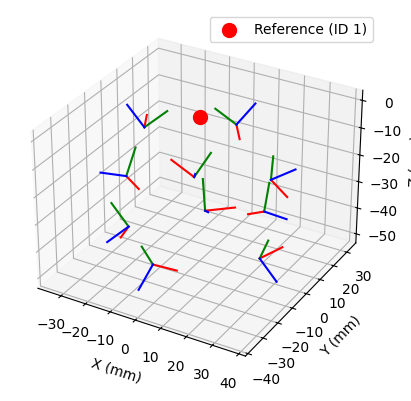

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Reference at origin
ax.scatter(0,0,0, c='r', s=100, label="Reference (ID 1)")

for marker_id, T in optimized_transforms.items():
    t = T[:3,3]
    #ax.scatter(t[0], t[1], t[2], label=f"Marker {marker_id}")

    # draw small coordinate axes
    R_mat = T[:3,:3]
    axis_length = 10

    x_axis = t + R_mat[:,0] * axis_length
    y_axis = t + R_mat[:,1] * axis_length
    z_axis = t + R_mat[:,2] * axis_length

    ax.plot([t[0], x_axis[0]],
            [t[1], x_axis[1]],
            [t[2], x_axis[2]], c='r')

    ax.plot([t[0], y_axis[0]],
            [t[1], y_axis[1]],
            [t[2], y_axis[2]], c='g')

    ax.plot([t[0], z_axis[0]],
            [t[1], z_axis[1]],
            [t[2], z_axis[2]], c='b')

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.legend()
plt.show()


In [13]:
np.savez("dodeca_marker_poses.npz",
         optimized_transforms=optimized_transforms,
         images_data=images_data,
         relative_transforms=relative_transforms)

In [14]:
for marker_id, T in optimized_transforms.items():
    print(marker_id, np.linalg.norm(T[:3,3]))

5 31.908685362489823
10 31.84455604851099
0 27.128509742915213
6 49.81488240711414
2 29.993021533676583
4 49.09533128587286
11 30.716930488693837
3 38.57345794182508
9 50.557425928483916
8 49.28857478499871


In [15]:
import itertools

marker_ids = list(optimized_transforms.keys())

for m1, m2 in itertools.combinations(marker_ids, 2):
    t1 = optimized_transforms[m1][:3,3]
    t2 = optimized_transforms[m2][:3,3]
    dist = np.linalg.norm(t1 - t2)
    print(f"{m1} ↔ {m2} : {dist:.4f} mm")

5 ↔ 10 : 28.4988 mm
5 ↔ 0 : 29.4538 mm
5 ↔ 6 : 25.7755 mm
5 ↔ 2 : 50.7242 mm
5 ↔ 4 : 28.6794 mm
5 ↔ 11 : 48.9912 mm
5 ↔ 3 : 39.5344 mm
5 ↔ 9 : 56.0061 mm
5 ↔ 8 : 47.9564 mm
10 ↔ 0 : 46.0201 mm
10 ↔ 6 : 26.3847 mm
10 ↔ 2 : 48.5825 mm
10 ↔ 4 : 46.6681 mm
10 ↔ 11 : 30.9567 mm
10 ↔ 3 : 46.1346 mm
10 ↔ 9 : 46.6290 mm
10 ↔ 8 : 26.6114 mm
0 ↔ 6 : 50.5162 mm
0 ↔ 2 : 32.0400 mm
0 ↔ 4 : 31.3984 mm
0 ↔ 11 : 47.2619 mm
0 ↔ 3 : 24.5473 mm
0 ↔ 9 : 50.2197 mm
0 ↔ 8 : 58.4074 mm
6 ↔ 2 : 63.0884 mm
6 ↔ 4 : 34.5262 mm
6 ↔ 11 : 52.4442 mm
6 ↔ 3 : 48.6514 mm
6 ↔ 9 : 53.7977 mm
6 ↔ 8 : 35.9607 mm
2 ↔ 4 : 51.3835 mm
2 ↔ 11 : 28.4262 mm
2 ↔ 3 : 26.2181 mm
2 ↔ 9 : 33.4109 mm
2 ↔ 8 : 50.3693 mm
4 ↔ 11 : 57.6981 mm
4 ↔ 3 : 27.6373 mm
4 ↔ 9 : 47.9520 mm
4 ↔ 8 : 51.8944 mm
11 ↔ 3 : 40.3712 mm
11 ↔ 9 : 31.3448 mm
11 ↔ 8 : 29.7326 mm
3 ↔ 9 : 28.7894 mm
3 ↔ 8 : 46.0400 mm
9 ↔ 8 : 31.0319 mm


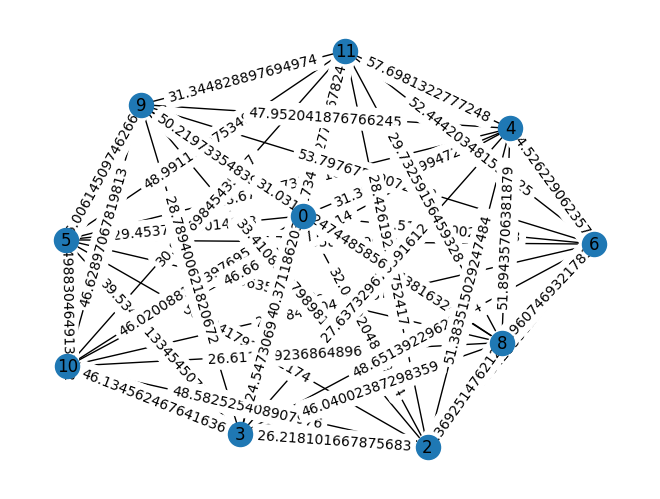

In [16]:
import networkx as nx

G = nx.Graph()

for m1, m2 in itertools.combinations(marker_ids, 2):
    t1 = optimized_transforms[m1][:3,3]
    t2 = optimized_transforms[m2][:3,3]
    dist = np.linalg.norm(t1 - t2)
    G.add_edge(m1, m2, weight=dist)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
plt.show()

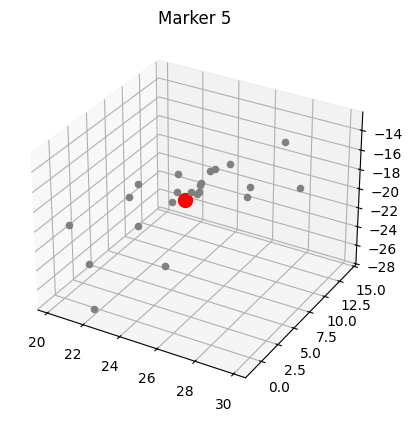

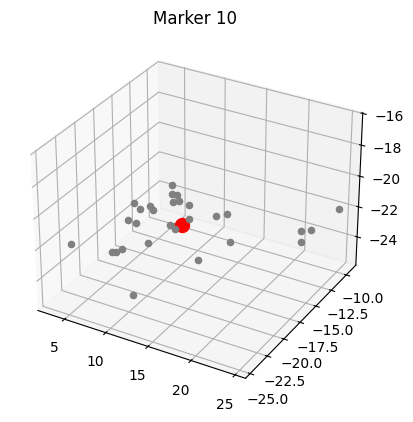

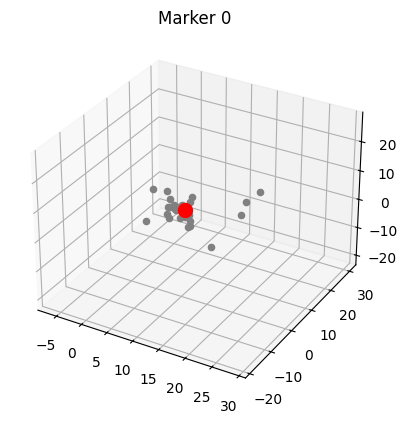

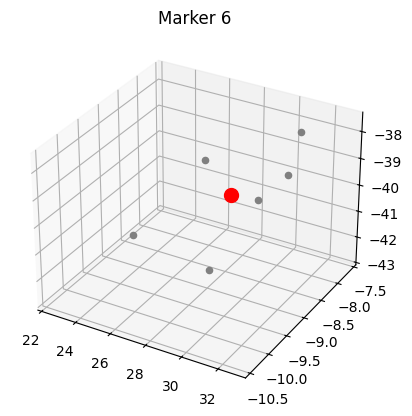

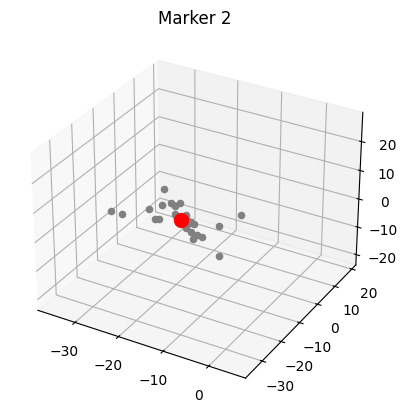

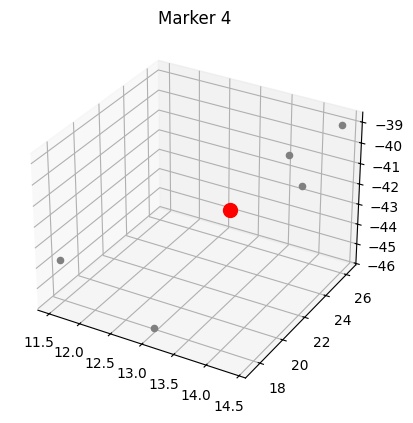

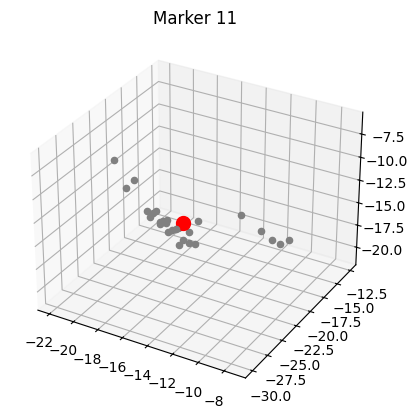

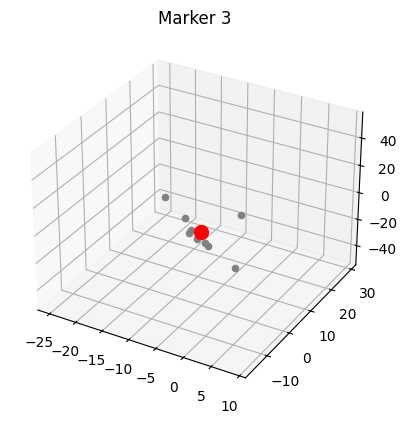

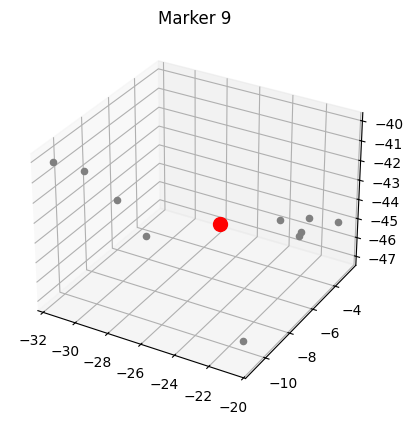

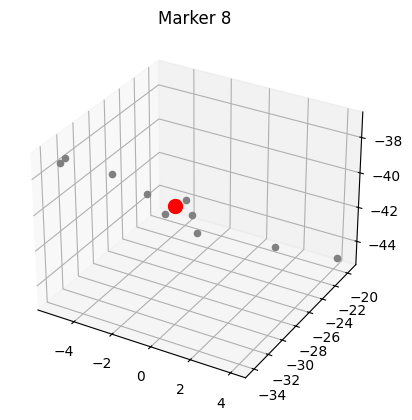

In [17]:
for marker_id, transforms in relative_transforms.items():

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # raw estimates
    for T in transforms:
        t = T[:3,3]
        ax.scatter(t[0], t[1], t[2], c='gray')

    # optimized
    T_opt = optimized_transforms[marker_id]
    t_opt = T_opt[:3,3]
    ax.scatter(t_opt[0], t_opt[1], t_opt[2], c='red', s=100)

    ax.set_title(f"Marker {marker_id}")
    plt.show()


In [10]:
import numpy as np
import cv2

def get_4x4_matrix(rvec, tvec):
    R, _ = cv2.Rodrigues(rvec)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = tvec.flatten()
    return T
# -------------------------------
# 1. Build pairwise relative edges
# -------------------------------
pairwise_edges = {}

for img_idx, markers in images_data.items():

    marker_ids = list(markers.keys())

    for i in range(len(marker_ids)):
        for j in range(i+1, len(marker_ids)):

            id_a = marker_ids[i]
            id_b = marker_ids[j]

            rvec_a, tvec_a = markers[id_a]
            rvec_b, tvec_b = markers[id_b]

            T_ca = get_4x4_matrix(rvec_a, tvec_a)
            T_cb = get_4x4_matrix(rvec_b, tvec_b)

            T_ab = np.linalg.inv(T_ca) @ T_cb

            edge_key = tuple(sorted((id_a, id_b)))

            if id_a > id_b:
                T_final = np.linalg.inv(T_ab)
            else:
                T_final = T_ab

            if edge_key not in pairwise_edges:
                pairwise_edges[edge_key] = []

            pairwise_edges[edge_key].append(T_final)


print("Total edges:", len(pairwise_edges))

Total edges: 29


In [ ]:
for key, vals in pairwise_edges.items():
    print(key, len(vals))
# Degree of each node
degree = {}

for (i,j) in pairwise_edges.keys():
    degree[i] = degree.get(i,0)+1
    degree[j] = degree.get(j,0)+1

print(degree)
MIN_OBS = 5
pairwise_edges = {
    k: v for k,v in pairwise_edges.items()
    if len(v) >= MIN_OBS
}


In [21]:
# -------------------------------
# 2. Initialize global poses
# -------------------------------
marker_ids = sorted(list(set([e[0] for e in edges] + [e[1] for e in edges])))

global_poses = {}

for mid in marker_ids:
    global_poses[mid] = np.eye(4)

# Fix anchor
anchor_id = 7
global_poses[anchor_id] = np.eye(4)


In [22]:
from scipy.spatial.transform import Rotation as R

def se3_log(T):
    R_mat = T[:3, :3]
    t = T[:3, 3]
    rotvec = R.from_matrix(R_mat).as_rotvec()
    return np.hstack((rotvec, t))


def se3_exp(xi):
    rotvec = xi[:3]
    t = xi[3:]
    R_mat = R.from_rotvec(rotvec).as_matrix()
    T = np.eye(4)
    T[:3, :3] = R_mat
    T[:3, 3] = t
    return T


In [23]:
for key, transforms in pairwise_edges.items():
    logs = [se3_log(T) for T in transforms]
    norms = [np.linalg.norm(l) for l in logs]
    print(key, np.std(norms))

(np.int32(10), np.int32(11)) 1.4601910183095215
(np.int32(2), np.int32(11)) 9.851267905315432
(np.int32(2), np.int32(10)) 2.400097704778262
(np.int32(7), np.int32(11)) 3.3699842078535682
(np.int32(7), np.int32(10)) 1.5934735377290337
(np.int32(5), np.int32(11)) 3.911189094377714
(np.int32(1), np.int32(11)) 2.9155156912055986
(np.int32(5), np.int32(6)) 3.332924047333465
(np.int32(1), np.int32(5)) 5.303836023124969
(np.int32(5), np.int32(7)) 3.092690400589458
(np.int32(9), np.int32(10)) 2.6028270673868708
(np.int32(3), np.int32(10)) 1.7502330355109617
(np.int32(3), np.int32(9)) 0.9383771334337182
(np.int32(7), np.int32(9)) 3.2193681340048346
(np.int32(4), np.int32(7)) 3.2453453383126347
(np.int32(4), np.int32(5)) 2.055197053831839
(np.int32(4), np.int32(6)) 5.230951992544188
(np.int32(7), np.int32(8)) 1.129255712166291
(np.int32(4), np.int32(9)) 4.464771912156495
(np.int32(4), np.int32(8)) 1.6674435473933666
(np.int32(8), np.int32(9)) 1.8830457440834907
(np.int32(6), np.int32(8)) 2.43556

In [24]:
def pose_graph_optimize(global_poses, edges, anchor_id, iterations=10):

    marker_ids = list(global_poses.keys())
    id_to_idx = {mid: i for i, mid in enumerate(marker_ids)}
    residual_history = []

    for it in range(iterations):

        A = []
        b = []
        total_error = 0
        

        for (i, j, T_ij) in edges:

            if i == anchor_id and j == anchor_id:
                continue

            Ti = global_poses[i]
            Tj = global_poses[j]

            # error transform
            Tij_pred = np.linalg.inv(Ti) @ Tj
            error_T = np.linalg.inv(T_ij) @ Tij_pred

            r = se3_log(error_T)
            total_error += np.linalg.norm(r)

            row = np.zeros((6, 6 * len(marker_ids)))

            if i != anchor_id:
                idx_i = id_to_idx[i]
                row[:, 6*idx_i:6*(idx_i+1)] = -np.eye(6)

            if j != anchor_id:
                idx_j = id_to_idx[j]
                row[:, 6*idx_j:6*(idx_j+1)] = np.eye(6)

            A.append(row)
            b.append(-r.reshape(6,1))

        if not A:
            continue

        A = np.vstack(A)
        b = np.vstack(b)

        # Solve normal equations
        lambda_damping = 1e-3
        AtA = A.T @ A
        Atb = A.T @ b

        dx = np.linalg.solve(
            AtA + lambda_damping * np.eye(AtA.shape[0]),
            Atb
        )
        step_scale = 0.1 

        # Update poses
        for mid in marker_ids:

            if mid == anchor_id:
                continue

            idx = id_to_idx[mid]
            delta = dx[6*idx:6*(idx+1)].flatten()

            global_poses[mid] = global_poses[mid] @ se3_exp(step_scale*delta)

        residual_history.append(total_error)

        print(f"Iteration {it+1}")
        print(f"   Total residual: {total_error:.6f}")
        print(f"   Update norm: {np.linalg.norm(dx):.6f}")
        print("-"*40)

    return global_poses, residual_history


In [25]:
optimized_poses, residual_history = pose_graph_optimize(
    global_poses,
    edges,
    anchor_id=7,
    iterations=15
)

In [49]:
import numpy as np
import cv2
import glob
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation as R

# ==========================================
# 1. LOAD CALIBRATION & DATASET
# ==========================================
data = np.load(r"E:\Sanjay\Dodeca\realsense_rgb_calibration.npz")
K = data["camera_matrix"]
D = data["dist_coeffs"]

marker_length = 20.0
# Ideal 3D corners of a marker (local frame)
obj_points = np.array([
    [-marker_length/2,  marker_length/2, 0],
    [ marker_length/2,  marker_length/2, 0],
    [ marker_length/2, -marker_length/2, 0],
    [-marker_length/2, -marker_length/2, 0]
], dtype=np.float32)

# ==========================================
# 2. INITIAL ESTIMATION (APE)
# ==========================================
# We use your existing logic to get starting values for the optimizer
images = glob.glob("dodeca_pentip_dataset/*.jpg")
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
detector = cv2.aruco.ArucoDetector(aruco_dict, cv2.aruco.DetectorParameters())

observations = [] # Stores (image_idx, marker_id, 2d_corners)
initial_camera_poses = {} # {img_idx: [rvec, tvec]}
initial_marker_poses = {} # {marker_id: [rvec, tvec]} (Relative to Anchor)

anchor_id = 0

for idx, img_path in enumerate(images):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    corners, ids, _ = detector.detectMarkers(gray)

    if ids is not None:
        ids = ids.flatten()
        # Initial guess for camera pose using ArUco PnP
        # Equation (2): Er(p) = sum(u_hat - u(p))^2
        success, r, t = cv2.solvePnP(obj_points, corners[0], K, D)
        initial_camera_poses[idx] = np.concatenate([r.flatten(), t.flatten()])

        for i, m_id in enumerate(ids):
            observations.append({
                'img_idx': idx,
                'marker_id': m_id,
                'uv': corners[i].reshape(-1, 2)
            })
            if m_id not in initial_marker_poses:
                initial_marker_poses[m_id] = np.array([0,0,0,0,0,0], dtype=np.float64)

# ==========================================
# 3. BUNDLE ADJUSTMENT (Optimization)
# ==========================================
def params_to_6dof(params):
    """Converts 6D vector (3 rot, 3 trans) to rvec and tvec."""
    return params[:3], params[3:]

def objective_function(params, n_images, n_markers, observations, marker_id_map):
    """
    Mathematical Implementation of Equation (8):
    Ea = sum( Ic(ui(pj; pk)) - Ot(xi) )^2
    """
    errors = []
    
    # Extract camera poses from params
    cam_start = 0
    marker_start = n_images * 6
    
    for obs in observations:
        img_idx = obs['img_idx']
        m_id = obs['marker_id']
        uv_observed = obs['uv']
        
        # Get 6DoF for camera and marker
        c_params = params[img_idx*6 : img_idx*6 + 6]
        m_params = params[marker_start + marker_id_map[m_id]*6 : marker_start + marker_id_map[m_id]*6 + 6]
        
        r_cam, t_cam = params_to_6dof(c_params)
        r_mark, t_mark = params_to_6dof(m_params)
        
        # PROJECT: Dodecahedron Frame -> Camera Frame -> Pixel Frame
        # Step 1: Transform marker corners by marker pose (p_j)
        R_m, _ = cv2.Rodrigues(r_mark)
        pts_3d_dodeca = (R_m @ obj_points.T).T + t_mark
        
        # Step 2: Project 3D points to 2D using camera pose (p_k)
        uv_projected, _ = cv2.projectPoints(pts_3d_dodeca, r_cam, t_cam, K, D)
        uv_projected = uv_projected.reshape(-1, 2)
        
        # Step 3: Calculate Residual (Projection Error)
        errors.append((uv_projected - uv_observed).flatten())
        
    return np.concatenate(errors)

# Prepare mapping for optimizer
marker_ids = sorted(list(initial_marker_poses.keys()))
marker_id_map = {m_id: i for i, m_id in enumerate(marker_ids)}

# Flatten all initial guesses into one long vector
# [Cam0_6DoF, Cam1_6DoF... Marker0_6DoF, Marker1_6DoF...]
x0 = []
for i in range(len(images)):
    x0.extend(initial_camera_poses.get(i, [0]*6))
for m_id in marker_ids:
    x0.extend(initial_marker_poses[m_id])

x0 = np.array(x0)

print("Starting Bundle Adjustment...")
# Gauss-Newton / Levenberg-Marquardt Optimization
res = least_squares(
    objective_function, 
    x0, 
    args=(len(images), len(marker_ids), observations, marker_id_map),
    verbose=2,
    ftol=1e-4,
    xtol=1e-4
)

# ==========================================
# 4. EXTRACT REFINED MODEL
# ==========================================
optimized_params = res.x
marker_start = len(images) * 6
final_model = {}

for i, m_id in enumerate(marker_ids):
    p = optimized_params[marker_start + i*6 : marker_start + i*6 + 6]
    final_model[m_id] = p
    print(f"Refined Marker {m_id} Pose: {p}")

print("\nCalibration Complete. You now have a precise 3D model of your dodecahedron.")

Starting Bundle Adjustment...
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.3170e+06                                    3.76e+04    
       1              3         5.3447e+05      7.83e+05       1.23e+03       2.32e+05    
       2              8         3.2575e+05      2.09e+05       9.62e+00       8.53e+04    
       3              9         2.3815e+05      8.76e+04       1.92e+01       2.60e+04    
       4             10         1.8527e+05      5.29e+04       3.85e+01       7.66e+03    
       5             11         1.4984e+05      3.54e+04       7.70e+01       3.40e+04    
       6             13         1.4087e+05      8.97e+03       3.85e+01       6.06e+04    
       7             14         1.0608e+05      3.48e+04       3.85e+01       1.86e+04    
       8             15         8.6794e+04      1.93e+04       7.70e+01       1.29e+04    
       9             17         7.4402e+04      1.24e+04    

KeyboardInterrupt: 

In [33]:
# Create the "Master Model"
all_obj_points = []
for m_id, pose in final_model.items():
    rvec, tvec = pose[:3], pose[3:]
    R_mat, _ = cv2.Rodrigues(rvec)
    
    # Transform local corners to the Dodecahedron Model Space
    # P_model = R * P_local + T 
    marker_corners_in_model = (R_mat @ obj_points.T).T + tvec
    all_obj_points.append(marker_corners_in_model)

# Flatten into one big 3D point cloud for solvePnP
dodecahedron_3d_model = np.vstack(all_obj_points)

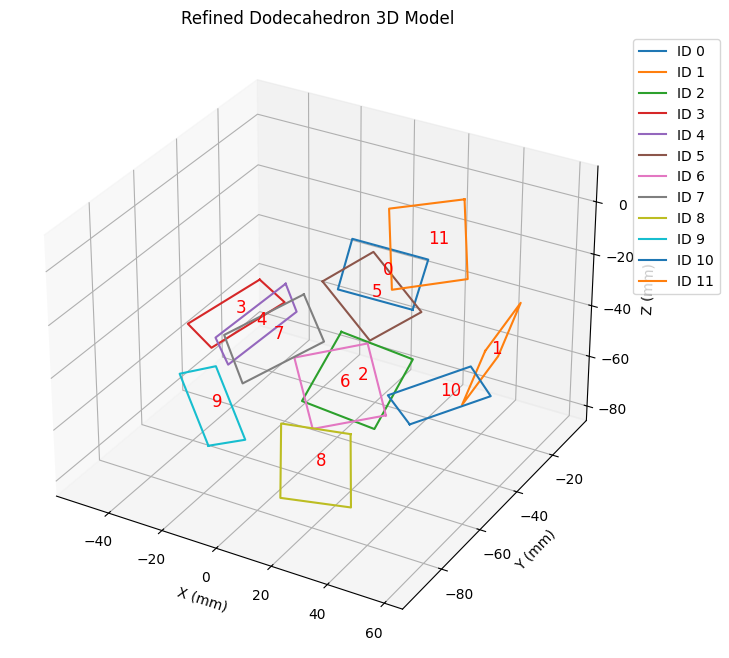

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_dodecahedron_model(final_model):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for m_id, pose in final_model.items():
        rvec, tvec = pose[:3], pose[3:]
        R_mat, _ = cv2.Rodrigues(rvec)
        
        # Calculate corners in the Dodecahedron Model space
        corners_3d = (R_mat @ obj_points.T).T + tvec
        
        # Plot the marker face (closed loop)
        face = np.vstack([corners_3d, corners_3d[0]])
        ax.plot(face[:, 0], face[:, 1], face[:, 2], label=f'ID {m_id}')
        
        # Add ID label at the center of the marker
        center = tvec
        ax.text(center[0], center[1], center[2], str(m_id), color='red', fontsize=12)

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_zlabel('Z (mm)')
    ax.set_title('Refined Dodecahedron 3D Model')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()

plot_dodecahedron_model(final_model)

In [35]:
def visualize_reprojection(img_idx, images, optimized_params, observations, marker_ids):
    img = cv2.imread(images[img_idx])
    
    # Extract camera pose for this specific image from the optimized vector
    cam_params = optimized_params[img_idx*6 : img_idx*6 + 6]
    r_cam, t_cam = cam_params[:3], cam_params[3:]
    
    marker_start = len(images) * 6
    
    for i, m_id in enumerate(marker_ids):
        # Extract refined marker pose
        m_params = optimized_params[marker_start + i*6 : marker_start + i*6 + 6]
        r_mark, t_mark = m_params[:3], m_params[3:]
        
        # Transform local corners to Dodecahedron space, then project to Image
        R_m, _ = cv2.Rodrigues(r_mark)
        pts_3d_dodeca = (R_m @ obj_points.T).T + t_mark
        
        # Project using the optimized camera pose
        uv_pred, _ = cv2.projectPoints(pts_3d_dodeca, r_cam, t_cam, K, D)
        
        # Draw projected corners (Green)
        for pt in uv_pred:
            cv2.circle(img, tuple(pt.reshape(-1).astype(int)), 5, (0, 255, 0), -1)
            
    cv2.imshow(f"Reprojection Image {img_idx}", img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# Visualize the first image in your dataset
visualize_reprojection(0, images, res.x, observations, marker_ids)

In [16]:
import numpy as np
import cv2
import glob
from scipy.spatial.transform import Rotation
import os
from typing import List, Tuple, Dict
from scipy.optimize import least_squares
# ────────────────────────────────────────────────
#  CONFIGURATION
# ────────────────────────────────────────────────

MARKER_LENGTH_MM = 20.0          # physical edge length of each ArUco marker
ARUCO_DICT = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
ARUCO_PARAMS = cv2.aruco.DetectorParameters()
# You can tune these if detection is unstable
ARUCO_PARAMS.adaptiveThreshConstant = 5
ARUCO_PARAMS.cornerRefinementMethod = cv2.aruco.CORNER_REFINE_SUBPIX

# Paths
CALIB_FILE = r"E:\Sanjay\Dodeca\realsense_rgb_calibration_1.npz"
IMAGE_FOLDER = "dodeca_pentip_dataset"
IMAGE_PATTERN = os.path.join(IMAGE_FOLDER, "*.jpg")

# Which marker id we FIX as reference (anchor)
FIXED_MARKER_ID = 1

# Optimization settings
MAX_ITERATIONS = 50
CONVERGENCE_TOL = 1e-6          # change in cost
STEP_TOL       = 1e-8           # change in parameters

# ────────────────────────────────────────────────
#  HELPERS
# ────────────────────────────────────────────────

def get_marker_object_points(marker_length: float) -> np.ndarray:
    """ Returns 3D corners of one marker in its local coordinate system (z=0 plane) """
    s = marker_length / 2.0
    # Order: top-left, top-right, bottom-right, bottom-left  (OpenCV convention)
    objp = np.array([
        [-s,  s, 0],
        [ s,  s, 0],
        [ s, -s, 0],
        [-s, -s, 0]
    ], dtype=np.float32)
    return objp


def collect_detections(images: List[str]) -> List[Dict]:
    detector = cv2.aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMS)
    detections = []

    for path in images:
        img = cv2.imread(path)
        if img is None:
            print(f"Cannot read {path}")
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        marker_corners, ids, rejectedImgPoints = detector.detectMarkers(gray)

        if ids is None or len(ids) == 0:
            print(f"No markers in {os.path.basename(path)}")
            continue

        ids = ids.ravel()  # shape (N,)

        # ── Handle the corners correctly (most important fix) ───────────────
        if isinstance(marker_corners, tuple):
            # New style: tuple of per-marker arrays
            corners_list = [c[0] for c in marker_corners]          # each → (4,2)
        else:
            # Old style: (N,1,4,2)
            corners_list = [c[0] for c in marker_corners]          # same

        # Now stack them into standard (N,4,2) float32
        corners = np.stack(corners_list, axis=0).astype(np.float32)
        # ───────────────────────────────────────────────────────────────────

        detections.append({
            'path': path,
            'image': img,
            'gray': gray,
            'ids': ids,
            'corners': corners
        })

    print(f"Found {len(detections)} images with markers")
    return detections
    """
    Simple PnP → gives rough initial guess for camera pose in this image
    Returns success, rvec, tvec
    """
    obj_points_all = []
    img_points_all = []

    marker_obj = get_marker_object_points(marker_length)

    for j, mid in enumerate(ids_i):
        obj_points_all.append(marker_obj)
        img_points_all.append(corners_i[j])

    obj_points_all = np.vstack(obj_points_all)
    img_points_all = np.vstack(img_points_all)

    success, rvec, tvec = cv2.solvePnP(
        obj_points_all, img_points_all,
        K, D,
        flags=cv2.SOLVEPNP_ITERATIVE
    )

    return success, rvec, tvec


def axis_angle_to_matrix(rvec: np.ndarray) -> np.ndarray:
    return Rotation.from_rotvec(rvec.ravel()).as_matrix()


def matrix_to_axis_angle(R: np.ndarray) -> np.ndarray:
    return Rotation.from_matrix(R).as_rotvec()


# ────────────────────────────────────────────────
#  MAIN CALIBRATION FUNCTION
# ────────────────────────────────────────────────

def dodecahedron_calibration():
    # 1. Load camera calibration
    data = np.load(CALIB_FILE)
    K = data["camera_matrix"].astype(np.float64)
    D = data["dist_coeffs"].astype(np.float64).ravel()   # usually (4,) or (5,)

    # 2. Find images
    image_paths = sorted(glob.glob(IMAGE_PATTERN))
    if not image_paths:
        print("No images found!")
        return

    print(f"Found {len(image_paths)} images")

    # 3. Detect markers in all images
    detections = collect_detections(image_paths)

    if len(detections) < 6:
        print("Too few good images — need at least 6–10 for stable calibration")
        return

    # 4. Collect all observations
    observations = []  # list of (image_idx, marker_id, img_corners_4x2)

    for img_idx, det in enumerate(detections):
        for k, mid in enumerate(det['ids']):
            observations.append((img_idx, int(mid), det['corners'][k]))

    # Find all unique marker ids present in dataset
    all_marker_ids = sorted(set(mid for _, mid, _ in observations))
    print(f"Detected marker IDs: {all_marker_ids}")

    if FIXED_MARKER_ID not in all_marker_ids:
        print(f"Fixed marker {FIXED_MARKER_ID} not found → exiting")
        return

    # 5. Initial guesses
    # ─────────────────
    # Per image: rough camera pose w.r.t. dodecahedron (world = dodecahedron)
    cam_poses_init = [None] * len(detections)           # list of (rvec, tvec)
    marker_poses_init = {}                               # marker_id → (rvec, tvec) w.r.t dodecahedron

    # A. Rough camera poses per image (using all visible markers)
    for img_idx, det in enumerate(detections):
        success, rvec, tvec = get_single_frame_pose(
            det['corners'], det['ids'], K, D, MARKER_LENGTH_MM
        )
        if success:
            cam_poses_init[img_idx] = (rvec.ravel(), tvec.ravel())
        else:
            cam_poses_init[img_idx] = (np.zeros(3), np.array([0.,0.,300.]))  # fallback

    # B. Rough marker poses w.r.t. dodecahedron
    #    We use images where FIXED_MARKER_ID is visible as reference
    ref_images = [i for i, det in enumerate(detections) if FIXED_MARKER_ID in det['ids']]

    if not ref_images:
        print("No image contains the fixed marker → cannot initialize")
        return

    # Simple heuristic: average transform from fixed marker to camera over good views
    from_fixed_to_cam = []
    for i in ref_images:
        r_cam, t_cam = cam_poses_init[i]
        idx = np.where(detections[i]['ids'] == FIXED_MARKER_ID)[0][0]
        corners_fixed = detections[i]['corners'][idx]

        _, r_mk, t_mk = cv2.solvePnP(
            get_marker_object_points(MARKER_LENGTH_MM),
            corners_fixed, K, D
        )

        # cTw = [R|t]   → world = dodecahedron
        # mTw = marker-to-world = inv( marker-to-camera ) @ camera-to-world
        R_cam = axis_angle_to_matrix(r_cam)
        R_mk  = axis_angle_to_matrix(r_mk)

        R_m_c = R_mk.T
        t_m_c = -R_m_c @ t_mk.ravel()

        R_m_w = R_m_c @ R_cam
        t_m_w = R_m_c @ t_cam + t_m_c

        from_fixed_to_cam.append((R_m_w, t_m_w))

    # Average (very rough!)
    Rs = [r for r,t in from_fixed_to_cam]
    ts = [t for r,t in from_fixed_to_cam]

    R_avg = np.mean([axis_angle_to_matrix(Rotation.from_matrix(r).as_rotvec()) for r in Rs], axis=0)
    t_avg = np.mean(ts, axis=0)

    r_avg = matrix_to_axis_angle(R_avg)

    # Set fixed marker at origin
    marker_poses_init[FIXED_MARKER_ID] = (np.zeros(3, dtype=np.float64), np.zeros(3, dtype=np.float64))

    # Other markers: relative to fixed one (very approximate)
    for mid in all_marker_ids:
        if mid == FIXED_MARKER_ID:
            continue
        marker_poses_init[mid] = (r_avg.copy(), t_avg.copy() + np.random.randn(3)*5)  # small noise

    print("Initial marker poses created (rough)")

    # ────────────────────────────────────────────────
    # 6. Bundle Adjustment – sparse reprojection only
    # ────────────────────────────────────────────────

    # Parameters vector:
    #   [ cam_0_rvec(3), cam_0_tvec(3), cam_1_rvec(3), ... , cam_N_tvec(3) ,
    #     marker_1_rvec(3), marker_1_tvec(3), ... marker_M_tvec(3)  ]   (marker 0 fixed!)

    n_cams = len(detections)
    movable_markers = [m for m in all_marker_ids if m != FIXED_MARKER_ID]
    n_mov_markers = len(movable_markers)

    n_pose_params = n_cams * 6 + n_mov_markers * 6
    print(f"Total parameters = {n_pose_params}  ({n_cams} cameras + {n_mov_markers} movable markers)")

    # Map marker id → index in parameter block
    marker_param_idx = {mid: i for i, mid in enumerate(movable_markers)}

    # Build parameter vector
    x = np.zeros(n_pose_params, dtype=np.float64)

    # Fill camera poses
    for i in range(n_cams):
        r, t = cam_poses_init[i]
        offset = i * 6
        x[offset  :offset+3] = r
        x[offset+3:offset+6] = t

    # Fill movable marker poses
    for i, mid in enumerate(movable_markers):
        r, t = marker_poses_init[mid]
        offset = n_cams * 6 + i * 6
        x[offset  :offset+3] = r
        x[offset+3:offset+6] = t

    # ────────────────────────────────
    # Simple Gauss-Newton loop
    # ────────────────────────────────

    prev_cost = np.inf
    def bundle_residuals(x_flat):
        residuals = []
        
        for img_idx, marker_id, img_corners in observations:
            # same extraction of r_cam, t_cam, r_mkr, t_mkr as before
            cam_offset = img_idx * 6
            r_cam = x_flat[cam_offset  :cam_offset+3]
            t_cam = x_flat[cam_offset+3:cam_offset+6]

            if marker_id == FIXED_MARKER_ID:
                r_mkr = np.zeros(3)
                t_mkr = np.zeros(3)
            else:
                m_offset = n_cams * 6 + marker_param_idx[marker_id] * 6
                r_mkr = x_flat[m_offset  :m_offset+3]
                t_mkr = x_flat[m_offset+3:m_offset+6]

            R_m_w = Rotation.from_rotvec(r_mkr).as_matrix()
            R_c_w = Rotation.from_rotvec(r_cam).as_matrix()

            pts_marker = get_marker_object_points(MARKER_LENGTH_MM)
            pts_world = (R_m_w @ pts_marker.T + t_mkr[:, None]).T
            pts_cam   = (R_c_w @ pts_world.T + t_cam[:, None]).T

            proj, _ = cv2.projectPoints(pts_cam, np.zeros(3), np.zeros(3), K, D)
            proj = proj.squeeze()  # (4,2)

            res = (img_corners - proj).ravel()   # 8 elements
            residuals.append(res)

        return np.concatenate(residuals)


    # ────────────────────────────────────────────────
    # Run optimization
    # ────────────────────────────────────────────────

    print("Starting bundle adjustment with scipy.least_squares ...")

    res = least_squares(
        bundle_residuals,
        x,
        method='lm',                # Levenberg-Marquardt
        ftol=1e-6,
        xtol=1e-8,
        gtol=1e-8,
        max_nfev=2000,
        loss = 'huber',
        verbose=2                   # shows progress every iteration
    )

    x_opt = res.x
    print(f"Optimization result: success = {res.success}")
    print(f"Final cost = {0.5 * np.sum(res.fun**2):.2f}")
    n_residuals = len(res.fun)
    print(f"Avg reprojection error = {np.sqrt(np.mean(res.fun**2)):.4f} pixels")

    # ────────────────────────────────────────────────
    # Save result
    # ────────────────────────────────────────────────

    result = {
        "K": K,
        "D": D,
        "marker_length_mm": MARKER_LENGTH_MM,
        "fixed_marker_id": FIXED_MARKER_ID,
        "marker_poses": {}   # id → (rvec, tvec)
    }

    # Fixed marker
    result["marker_poses"][FIXED_MARKER_ID] = (np.zeros(3), np.zeros(3))

    # Movable markers
    for i, mid in enumerate(movable_markers):
        offset = n_cams * 6 + i * 6
        r = x[offset  :offset+3]
        t = x[offset+3:offset+6]
        result["marker_poses"][mid] = (r, t)

    # Optional: save camera poses too if useful
    np.savez("dodecahedron_calibration_result.npz", **result)
    print("Calibration saved to dodecahedron_calibration_result.npz")


if __name__ == "__main__":
    dodecahedron_calibration()

Found 120 images
Found 120 images with markers
Detected marker IDs: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 157]


NameError: name 'get_single_frame_pose' is not defined

In [ ]:
    for iter in range(MAX_ITERATIONS):
        J = []
        residuals = []

        for img_idx, marker_id, img_corners in observations:
            # Get current parameters
            cam_offset = img_idx * 6
            r_cam = x[cam_offset  :cam_offset+3]
            t_cam = x[cam_offset+3:cam_offset+6]

            if marker_id == FIXED_MARKER_ID:
                r_mkr = np.zeros(3)
                t_mkr = np.zeros(3)
            else:
                m_offset = n_cams * 6 + marker_param_idx[marker_id] * 6
                r_mkr = x[m_offset  :m_offset+3]
                t_mkr = x[m_offset+3:m_offset+6]

            # World → marker → camera
            R_m_w = axis_angle_to_matrix(r_mkr)
            R_c_w = axis_angle_to_matrix(r_cam)

            # point in marker frame → dodeca world → camera frame
            pts_marker = get_marker_object_points(MARKER_LENGTH_MM)
            pts_world = (R_m_w @ pts_marker.T + t_mkr[:,None]).T
            pts_cam   = (R_c_w @ pts_world.T + t_cam[:,None]).T

            # Project
            proj, _ = cv2.projectPoints(
                pts_cam, np.zeros(3), np.zeros(3), K, D
            )
            proj = proj.reshape(-1, 2)

            # Residual = observed - projected
            res = (img_corners - proj).ravel()          # 8 values
            residuals.append(res)

            # ─── Jacobian approximation (finite diff for simplicity) ───
            eps = 1e-5
            J_row = np.zeros((8, n_pose_params))

            # Perturb each parameter
            for p in range(n_pose_params):
                x_pert = x.copy()
                x_pert[p] += eps
                # recompute proj_pert the same way (ugly but clear)
                # ... (you would re-extract r_cam, t_cam, r_mkr, t_mkr from x_pert)
                # then recompute pts_cam_pert, project → proj_pert
                # J_row[:,p] = (proj_pert.ravel() - proj.ravel()) / eps

            # For real usage → implement analytical Jacobian or use scipy.optimize.least_squares

            J.append(J_row)

        residuals = np.concatenate(residuals)
        cost = 0.5 * np.sum(residuals ** 2)
        print(f"Iter {iter:2d}   cost = {cost:12.4f}   avg reproj = {np.sqrt(cost/len(residuals)*2):.4f} px")

        if abs(prev_cost - cost) < CONVERGENCE_TOL:
            print("Converged!")
            break

        prev_cost = cost

        # Solve J Δx = -residuals   (very simplified — real code needs proper solver)
        # For serious usage replace with:
        # from scipy.optimize import least_squares
        # or implement LevMar / Dogleg

In [1]:
import numpy as np
import cv2
import glob
import os
from scipy.spatial.transform import Rotation
from typing import List, Dict
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# CONFIGURATION
# ────────────────────────────────────────────────

MARKER_LENGTH_MM = 20.0          # marker size
ARUCO_DICT = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
ARUCO_PARAMS = cv2.aruco.DetectorParameters()
ARUCO_PARAMS.adaptiveThreshConstant = 5
ARUCO_PARAMS.cornerRefinementMethod = cv2.aruco.CORNER_REFINE_SUBPIX

CALIB_FILE = r"E:\Sanjay\Dodeca\realsense_rgb_calibration_1.npz"
IMAGE_FOLDER = "dodeca_pen_dataset"
IMAGE_PATTERN = os.path.join(IMAGE_FOLDER, "*.jpg")
FIXED_MARKER_ID = 1

In [2]:
def load_camera_calibration(calib_file: str):
    data = np.load(calib_file)
    K = data["camera_matrix"].astype(np.float64)
    D = data["dist_coeffs"].astype(np.float64).ravel()
    print("Camera matrix K:\n", K)
    print("Distortion coefficients D:\n", D)
    return K, D
K, D = load_camera_calibration(CALIB_FILE)

Camera matrix K:
 [[648.4221327    0.         639.41126285]
 [  0.         649.28455859 363.95789388]
 [  0.           0.           1.        ]]
Distortion coefficients D:
 [-0.06089643  0.0906475  -0.00094751  0.00034792 -0.04838556]


In [3]:
def collect_marker_observations(image_pattern: str, K, D, marker_length):

    image_paths = sorted(glob.glob(image_pattern))
    detector = cv2.aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMS)

    # 3D marker model (local marker frame)
    s = marker_length / 2.0
    marker_obj = np.array([
        [-s,  s, 0],
        [ s,  s, 0],
        [ s, -s, 0],
        [-s, -s, 0]
    ], dtype=np.float32)

    marker_observations = {}
    frame_count = 0

    for frame_idx, path in enumerate(image_paths):

        img = cv2.imread(path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        corners, ids, _ = detector.detectMarkers(gray)

        if ids is None:
            continue

        ids = ids.flatten()

        for i, marker_id in enumerate(ids):

            img_points = corners[i].reshape(-1, 2).astype(np.float32)

            success, rvec, tvec = cv2.solvePnP(
                marker_obj,
                img_points,
                K,
                D,
                flags=cv2.SOLVEPNP_IPPE_SQUARE
            )

            if not success:
                continue

            if marker_id not in marker_observations:
                marker_observations[marker_id] = []

            marker_observations[marker_id].append({
                "frame_idx": frame_idx,
                "rvec": rvec,
                "tvec": tvec
            })

        frame_count += 1

    print(f"Processed {frame_count} frames")
    print(f"Markers observed: {list(marker_observations.keys())}")

    return marker_observations

In [4]:
marker_observations = collect_marker_observations(
    IMAGE_PATTERN,
    K,
    D,
    MARKER_LENGTH_MM# use real marker size
)

Processed 46 frames
Markers observed: [np.int32(1), np.int32(11), np.int32(7), np.int32(5), np.int32(4), np.int32(6), np.int32(9), np.int32(10), np.int32(3), np.int32(8), np.int32(2)]


In [8]:
def rt_to_matrix(rvec, tvec):
    R, _ = cv2.Rodrigues(rvec)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = tvec.flatten()
    return T
for mid, obs_list in marker_observations.items():
    for obs in obs_list:
        obs["T_cm"] = rt_to_matrix(obs["rvec"], obs["tvec"])

In [9]:
frame_visibility = {}

for mid, obs_list in marker_observations.items():
    for obs in obs_list:
        f = obs["frame_idx"]
        if f not in frame_visibility:
            frame_visibility[f] = []
        frame_visibility[f].append(mid)

print("Frame connectivity:")
for f, markers in frame_visibility.items():
    print(f"Frame {f}: {markers}")

Frame connectivity:
Frame 0: [np.int32(1), np.int32(11)]
Frame 1: [np.int32(1), np.int32(11)]
Frame 4: [np.int32(1), np.int32(5), np.int32(6)]
Frame 16: [np.int32(1), np.int32(11)]
Frame 17: [np.int32(1), np.int32(11), np.int32(2)]
Frame 25: [np.int32(1), np.int32(5), np.int32(4), np.int32(6)]
Frame 26: [np.int32(1), np.int32(5), np.int32(4), np.int32(6), np.int32(8)]
Frame 27: [np.int32(1), np.int32(5), np.int32(6)]
Frame 3: [np.int32(11), np.int32(7), np.int32(5)]
Frame 9: [np.int32(11), np.int32(7), np.int32(9)]
Frame 12: [np.int32(11), np.int32(7)]
Frame 14: [np.int32(11), np.int32(2)]
Frame 20: [np.int32(11), np.int32(5)]
Frame 23: [np.int32(11), np.int32(2)]
Frame 28: [np.int32(11), np.int32(7), np.int32(9)]
Frame 33: [np.int32(11), np.int32(5)]
Frame 34: [np.int32(11), np.int32(2)]
Frame 36: [np.int32(11), np.int32(2)]
Frame 41: [np.int32(11), np.int32(7)]
Frame 2: [np.int32(7), np.int32(5), np.int32(4)]
Frame 6: [np.int32(7), np.int32(9), np.int32(10)]
Frame 10: [np.int32(7), n

In [10]:
for mid, obs_list in marker_observations.items():
    print(f"Marker {mid} observed {len(obs_list)} times")

Marker 1 observed 8 times
Marker 11 observed 15 times
Marker 7 observed 17 times
Marker 5 observed 17 times
Marker 4 observed 16 times
Marker 6 observed 6 times
Marker 9 observed 11 times
Marker 10 observed 3 times
Marker 3 observed 6 times
Marker 8 observed 3 times
Marker 2 observed 8 times


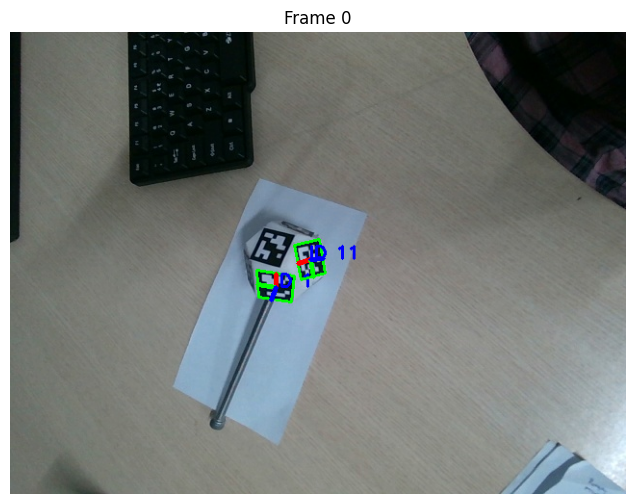

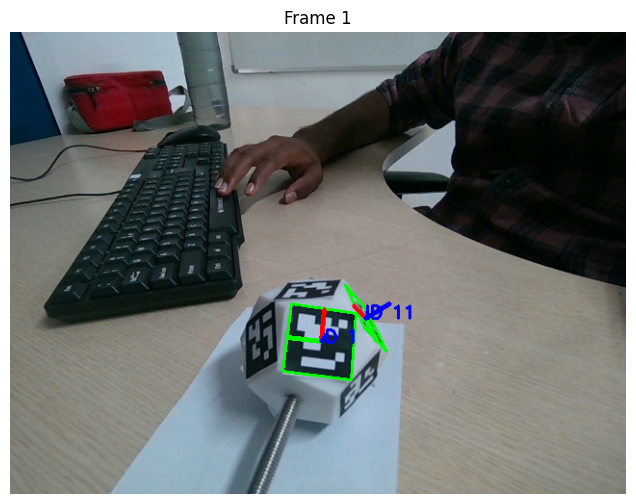

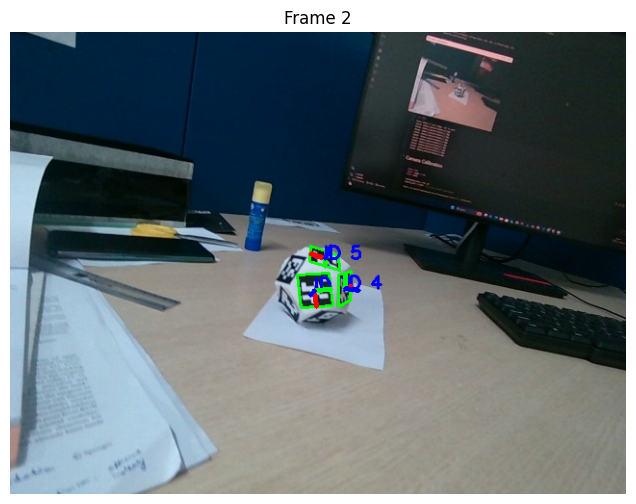

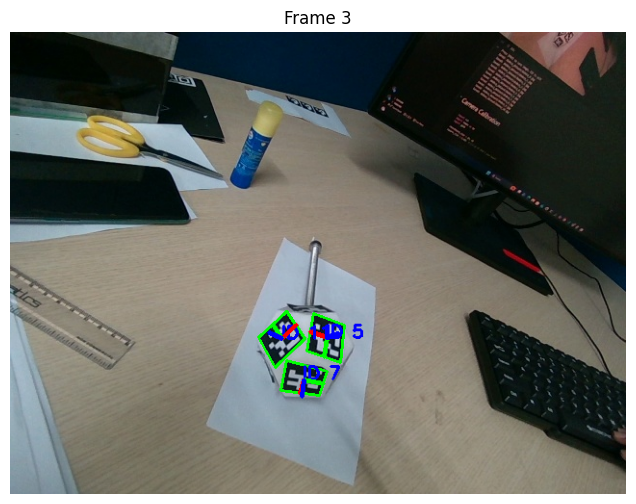

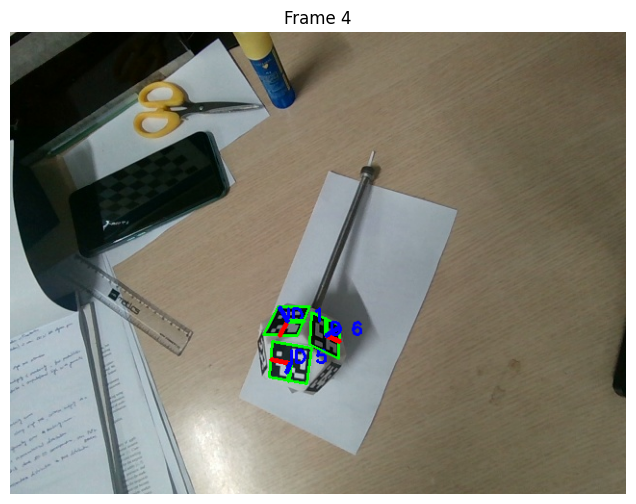

In [ ]:
# ────────────────────────────────────────────────
# VISUALIZE MARKER POSES AFTER PNP
# ────────────────────────────────────────────────

def visualize_marker_poses(image_pattern, K, D, marker_length, max_images=10):

    image_paths = sorted(glob.glob(image_pattern))
    detector = cv2.aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMS)

    axis_length = marker_length * 0.5

    for idx, path in enumerate(image_paths[:max_images]):

        img = cv2.imread(path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        corners, ids, _ = detector.detectMarkers(gray)

        if ids is None:
            continue

        ids = ids.flatten()

        s = marker_length / 2.0
        marker_obj = np.array([
            [-s,  s, 0],
            [ s,  s, 0],
            [ s, -s, 0],
            [-s, -s, 0]
        ], dtype=np.float32)

        for i, marker_id in enumerate(ids):

            img_points = corners[i].reshape(-1, 2).astype(np.float32)

            success, rvec, tvec = cv2.solvePnP(
                marker_obj,
                img_points,
                K,
                D,
                flags=cv2.SOLVEPNP_IPPE_SQUARE
            )

            if not success:
                continue
            cv2.polylines(
                img,
                [img_points.astype(int)],
                True,
                (0, 255, 0),
                2
            )
            center = img_points.mean(axis=0).astype(int)
            cv2.putText(
                img,
                f"ID {int(marker_id)}",
                tuple(center),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )
            cv2.drawFrameAxes(
                img,
                K,
                D,
                rvec,
                tvec,
                axis_length
            )
        # Show result
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Frame {idx}")
        plt.axis("off")
        plt.show()
visualize_marker_poses(
    IMAGE_PATTERN,
    K,
    D,
    MARKER_LENGTH_MM,
    max_images=5
)

In [3]:
# ────────────────────────────────────────────────
# STEP 1 — BUILD IDEAL MARKER POSES
# ────────────────────────────────────────────────

def create_ideal_marker_poses(edge_length=25.0):
    """
    Returns dictionary:
        marker_id -> (rvec, tvec) in object frame
    """

    phi = (1 + np.sqrt(5)) / 2
    a = edge_length

    # Normalized face centers of dodecahedron
    face_centers = [
        [0,  1/phi,  phi],
        [0, -1/phi,  phi],
        [0,  1/phi, -phi],
        [0, -1/phi, -phi],
        [ 1/phi,  phi, 0],
        [-1/phi,  phi, 0],
        [ 1/phi, -phi, 0],
        [-1/phi, -phi, 0],
        [ phi, 0,  1/phi],
        [-phi, 0,  1/phi],
        [ phi, 0, -1/phi],
        [-phi, 0, -1/phi],
    ]

    face_centers = np.array(face_centers)
    face_centers = face_centers / np.linalg.norm(face_centers, axis=1)[:, None]

    # Scale to approximate circumradius
    R = a * np.sqrt(3) / 2
    face_centers = face_centers * R

    marker_poses = {}

    for i, center in enumerate(face_centers[:11]):  # 11 markers
        normal = center / np.linalg.norm(center)

        # Choose arbitrary x-axis perpendicular to normal
        x_axis = np.array([1.0, 0.0, 0.0])
        if abs(np.dot(x_axis, normal)) > 0.9:
            x_axis = np.array([0.0, 1.0, 0.0])

        x_axis -= np.dot(x_axis, normal) * normal
        x_axis /= np.linalg.norm(x_axis)
        y_axis = np.cross(normal, x_axis)

        R_obj = np.column_stack([x_axis, y_axis, normal])
        rvec, _ = cv2.Rodrigues(R_obj)

        marker_poses[i] = {
            "rvec": rvec.flatten(),
            "tvec": center
        }

    return marker_poses

In [4]:
# ────────────────────────────────────────────────
# STEP 2 — DETECT MARKERS
# ────────────────────────────────────────────────

def detect_markers(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    detector = cv2.aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMS)
    corners, ids, _ = detector.detectMarkers(gray)
    return corners, ids

In [5]:
def compute_object_pose(corners, ids, marker_poses):
    obj_points = []
    img_points = []

    for corner, marker_id in zip(corners, ids.flatten()):
        if marker_id not in marker_poses:
            continue

        marker_pose = marker_poses[marker_id]
        rvec = marker_pose["rvec"]
        tvec = marker_pose["tvec"]

        R_marker, _ = cv2.Rodrigues(rvec)

        half = MARKER_LENGTH_MM / 2
        marker_corners = np.array([
            [-half,  half, 0],
            [ half,  half, 0],
            [ half, -half, 0],
            [-half, -half, 0]
        ])

        for i in range(4):
            X_obj = R_marker @ marker_corners[i] + tvec
            obj_points.append(X_obj)
            img_points.append(corner[0][i])

    if len(obj_points) < 6:
        return None

    obj_points = np.array(obj_points, dtype=np.float64)
    img_points = np.array(img_points, dtype=np.float64)

    success, rvec, tvec = cv2.solvePnP(
        obj_points, img_points, K, D, flags=cv2.SOLVEPNP_ITERATIVE
    )

    if not success:
        return None

    return rvec.flatten(), tvec.flatten()

In [6]:
import numpy as np
import cv2

# ────────────────────────────────────────────────
# CONFIG ── match your real camera & 6x6 markers
# ────────────────────────────────────────────────

MARKER_LENGTH_MM   = 20.0               # physical marker side length
ARUCO_DICT         = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
ARUCO_PARAMS       = cv2.aruco.DetectorParameters()
ARUCO_PARAMS.adaptiveThreshConstant    = 7
ARUCO_PARAMS.cornerRefinementMethod    = cv2.aruco.CORNER_REFINE_SUBPIX
ARUCO_PARAMS.minMarkerPerimeterRate    = 0.03      # help with small/distant markers
ARUCO_PARAMS.adaptiveThreshWinSizeMin  = 5
ARUCO_PARAMS.adaptiveThreshWinSizeMax  = 35

# ── Use your REAL camera intrinsics (from calibration)
K = np.array([
    [648.4221327,    0.0,       639.41126285],
    [  0.0,        649.28455859, 363.95789388],
    [  0.0,          0.0,         1.0        ]
], dtype=np.float64)

D = np.array([-0.06089643, 0.0906475, -0.00094751, 0.00034792, -0.04838556],
             dtype=np.float64)

# Simulation image size — should match your real images
image_size = (1280, 720)          # width, height

# ────────────────────────────────────────────────
# Improved create_ideal_marker_poses (correct circumradius)
# ────────────────────────────────────────────────

def create_ideal_marker_poses(edge_length=25.0):
    phi = (1 + np.sqrt(5)) / 2
    a = edge_length

    face_centers = np.array([
        [0,  1/phi,  phi], [0, -1/phi,  phi],
        [0,  1/phi, -phi], [0, -1/phi, -phi],
        [1/phi,  phi, 0],  [-1/phi,  phi, 0],
        [1/phi, -phi, 0],  [-1/phi, -phi, 0],
        [phi, 0,  1/phi],  [-phi, 0,  1/phi],
        [phi, 0, -1/phi],  [-phi, 0, -1/phi],
    ])

    # Normalize
    norms = np.linalg.norm(face_centers, axis=1, keepdims=True)
    face_centers /= norms

    # Correct circumradius of regular dodecahedron
    R_circum = a * (np.sqrt(3)/4.0) * (1.0 + np.sqrt(5))   # ≈ 35.03 mm for a=25
    face_centers *= R_circum

    marker_poses = {}

    for i, center in enumerate(face_centers[:11]):   # using 0..10
        normal = center / np.linalg.norm(center)

        x_axis = np.array([1.0, 0.0, 0.0])
        if abs(np.dot(x_axis, normal)) > 0.95:
            x_axis = np.array([0.0, 1.0, 0.0])

        x_axis = x_axis - np.dot(x_axis, normal) * normal
        norm_x = np.linalg.norm(x_axis)
        if norm_x < 1e-8:
            x_axis = np.array([0.0, 0.0, 1.0])  # fallback
            x_axis = x_axis - np.dot(x_axis, normal) * normal
            norm_x = np.linalg.norm(x_axis)
        x_axis /= norm_x

        y_axis = np.cross(normal, x_axis)

        R_obj = np.column_stack((x_axis, y_axis, normal))
        rvec, _ = cv2.Rodrigues(R_obj)

        marker_poses[i] = {
            "rvec": rvec.flatten(),
            "tvec": center.copy()
        }

    return marker_poses


# ────────────────────────────────────────────────
# Run & debug print
# ────────────────────────────────────────────────

marker_poses = create_ideal_marker_poses(edge_length=25.0)

print("Ideal marker poses built on dodecahedron faces using golden ratio.")
print("Unique markers defined:", len(marker_poses))
print(f"Circumradius used: {np.linalg.norm(marker_poses[0]['tvec']):.3f} mm")
print("\nExample marker 0:")
print("  rvec:", marker_poses[0]["rvec"].round(4))
print("  tvec:", marker_poses[0]["tvec"].round(3))

Ideal marker poses built on dodecahedron faces using golden ratio.
Unique markers defined: 11
Circumradius used: 35.031 mm

Example marker 0:
  rvec: [-0.3649  0.      0.    ]
  tvec: [ 0.    12.5   32.725]


In [21]:
import cv2
import numpy as np
import glob
import os

# ────────────────────────────────────────────────
# CONFIG
# ────────────────────────────────────────────────

MARKER_LENGTH_MM = 20.0
ARUCO_DICT = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
ARUCO_PARAMS = cv2.aruco.DetectorParameters()
ARUCO_PARAMS.adaptiveThreshConstant = 7
ARUCO_PARAMS.cornerRefinementMethod = cv2.aruco.CORNER_REFINE_SUBPIX
ARUCO_PARAMS.minMarkerPerimeterRate = 0.03

K = np.array([
    [648.4221327, 0.0, 639.41126285],
    [0.0, 649.28455859, 363.95789388],
    [0.0, 0.0, 1.0]
], dtype=np.float64)

D = np.array([-0.06089643, 0.0906475, -0.00094751, 0.00034792, -0.04838556], dtype=np.float64)

IMAGE_FOLDER = "dodeca_pentip_dataset"
IMAGE_PATTERN = os.path.join(IMAGE_FOLDER, "*.jpg")

# Assume this function exists (from your previous code)
# marker_poses = create_ideal_marker_poses(edge_length=25.0)

# ────────────────────────────────────────────────
# Load images & visualize detection + pose
# ────────────────────────────────────────────────

image_paths = sorted(glob.glob(IMAGE_PATTERN))  # sorted for consistent order
print(f"Found {len(image_paths)} images")

if len(image_paths) == 0:
    print("No images found.")
else:
    detector = cv2.aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMS)

    for idx, path in enumerate(image_paths[:8]):  # limit to first 8 for demo; change to all if needed
        print(f"\n[{idx+1}/{len(image_paths)}] {os.path.basename(path)}")

        img = cv2.imread(path)
        if img is None:
            print("  Failed to load")
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        corners, ids, rejected = detector.detectMarkers(gray)

        debug_img = img.copy()

        num_detected = len(ids) if ids is not None else 0

        if num_detected > 0:
            detected_ids = ids.flatten().tolist()
            print(f"  Detected {num_detected} markers → IDs: {detected_ids}")

            # Draw detections
            cv2.aruco.drawDetectedMarkers(debug_img, corners, ids, borderColor=(0, 255, 0))

            # Draw rejected (red)
            if rejected is not None and len(rejected) > 0:
                cv2.aruco.drawDetectedMarkers(debug_img, rejected, None, (0, 0, 255))

            # ─── Compute & visualize pose ──────────────────────────────────────
            pose_result = compute_object_pose(corners, ids, marker_poses)  # your function
            if pose_result is not None:
                rvec, tvec = pose_result
                print(f"  Pose → rvec: {rvec.round(4)}   tvec: {tvec.round(3)}")
                print(f"  Distance from camera: {np.linalg.norm(tvec):.1f} mm")

                # Project 3D axes for visual check (X=red, Y=green, Z=blue)
                axis_length = 40
                axis_points = np.float32([[0,0,0], [axis_length,0,0], [0,axis_length,0], [0,0,axis_length]])
                imgpts, _ = cv2.projectPoints(axis_points, rvec, tvec, K, D)
                imgpts = imgpts.astype(np.int32).reshape(-1, 2)

                origin = tuple(imgpts[0])
                cv2.line(debug_img, origin, tuple(imgpts[1]), (0,0,255), 4)   # X red
                cv2.line(debug_img, origin, tuple(imgpts[2]), (0,255,0), 4)   # Y green
                cv2.line(debug_img, origin, tuple(imgpts[3]), (255,0,0), 4)   # Z blue

                cv2.putText(debug_img, f"Dist: {np.linalg.norm(tvec):.0f}mm", 
                            (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,255), 2)

                # ─── Reprojection error visualization ─────────────────────────────
                obj_pts = []
                img_pts_measured = []

                for c, mid in zip(corners, ids.flatten()):
                    if mid not in marker_poses: continue
                    mp = marker_poses[mid]
                    Rm = cv2.Rodrigues(mp["rvec"])[0]
                    half = MARKER_LENGTH_MM / 2
                    mc = np.float32([[-half,half,0],[half,half,0],[half,-half,0],[-half,-half,0]])
                    obj_c = (Rm @ mc.T).T + mp["tvec"]
                    obj_pts.extend(obj_c)
                    img_pts_measured.extend(c[0])

                if len(obj_pts) >= 4:
                    obj_pts = np.array(obj_pts, dtype=np.float32)
                    img_pts_measured = np.array(img_pts_measured, dtype=np.float32)

                    proj, _ = cv2.projectPoints(obj_pts, rvec, tvec, K, D)
                    proj = proj.reshape(-1, 2)

                    error_px = np.linalg.norm(proj - img_pts_measured, axis=1)
                    mean_error = np.mean(error_px)
                    print(f"  Reproj error: mean = {mean_error:.2f} px")

                    # Draw error lines (yellow = measured → projected)
                    for meas, pr in zip(img_pts_measured, proj):
                        cv2.line(debug_img, tuple(meas.astype(int)), tuple(pr.astype(int)), (0,255,255), 1)

        else:
            print("  No markers detected")
            if rejected is not None and len(rejected) > 0:
                cv2.aruco.drawDetectedMarkers(debug_img, rejected, None, (0,0,255))
                print(f"  → {len(rejected)} rejected candidates")

        # Save & show
        debug_path = f"debug_real_{os.path.basename(path)}"
        #cv2.imwrite(debug_path, debug_img)
        print(f"  Saved: {debug_path}")

        cv2.imshow("Detection + Pose + Reproj", cv2.resize(debug_img, None, fx=0.6, fy=0.6))
        key = cv2.waitKey(0)
        if key == 27:  # ESC to stop
            break

    cv2.destroyAllWindows()

Found 120 images

[1/120] dodeca_0.jpg
  Detected 3 markers → IDs: [0, 5, 1]
  Pose → rvec: [ 2.0802 -0.4674 -1.7772]   tvec: [ -85.261  158.388 -578.127]
  Distance from camera: 605.5 mm
  Reproj error: mean = 19.53 px
  Saved: debug_real_dodeca_0.jpg

[2/120] dodeca_1.jpg
  Detected 3 markers → IDs: [0, 1, 5]
  Pose → rvec: [ 2.1314 -0.625  -1.7559]   tvec: [ -41.946  131.53  -563.877]
  Distance from camera: 580.5 mm
  Reproj error: mean = 19.65 px
  Saved: debug_real_dodeca_1.jpg

[3/120] dodeca_10.jpg
  Detected 4 markers → IDs: [0, 4, 3, 5]
  Pose → rvec: [0.6695 0.2693 4.4677]   tvec: [-144.042  198.888 -700.444]
  Distance from camera: 742.2 mm
  Reproj error: mean = 18.37 px
  Saved: debug_real_dodeca_10.jpg

[4/120] dodeca_100.jpg
  Detected 3 markers → IDs: [11, 9, 8]
  Pose → rvec: [-0.0568 -2.5935 -0.2415]   tvec: [-144.076  243.162 -953.526]
  Distance from camera: 994.5 mm
  Reproj error: mean = 8.99 px
  Saved: debug_real_dodeca_100.jpg

[5/120] dodeca_101.jpg
  Detecte

In [9]:
from scipy.optimize import least_squares
import numpy as np
import cv2

def pack_parameters(marker_poses, object_poses):
    params = []

    marker_ids = sorted(marker_poses.keys())

    # skip marker 0 (anchor)
    for j in marker_ids[1:]:
        params.extend(marker_poses[j]["rvec"])
        params.extend(marker_poses[j]["tvec"])

    for rvec, tvec in object_poses:
        params.extend(rvec)
        params.extend(tvec)

    return np.array(params, dtype=np.float64)

In [10]:
image_paths = sorted(glob.glob(IMAGE_PATTERN))

ideal_marker_poses = create_ideal_marker_poses()

object_poses = []
valid_images = []

for path in image_paths:
    img = cv2.imread(path)
    corners, ids = detect_markers(img)

    if ids is None:
        continue

    pose = compute_object_pose(corners, ids, ideal_marker_poses)
    if pose is None:
        continue

    object_poses.append(pose)
    valid_images.append((img, corners, ids))

In [11]:
def residual_function(params, marker_poses, valid_images):

    residuals = []
    idx = 0

    marker_ids = sorted(marker_poses.keys())

    # --- Update marker poses (except anchor 0)
    updated_marker_poses = {0: marker_poses[0]}

    for j in marker_ids[1:]:
        rvec = params[idx:idx+3]
        tvec = params[idx+3:idx+6]
        idx += 6
        updated_marker_poses[j] = {"rvec": rvec, "tvec": tvec}

    # --- Update object poses
    object_pose_list = []
    for _ in valid_images:
        rvec = params[idx:idx+3]
        tvec = params[idx+3:idx+6]
        idx += 6
        object_pose_list.append((rvec, tvec))

    # --- Compute reprojection residuals
    for (img, corners, ids), (rvec_obj, tvec_obj) in zip(valid_images, object_pose_list):

        R_obj, _ = cv2.Rodrigues(rvec_obj)

        for corner, marker_id in zip(corners, ids.flatten()):
            if marker_id not in updated_marker_poses:
                continue

            mp = updated_marker_poses[marker_id]
            R_marker, _ = cv2.Rodrigues(mp["rvec"])
            t_marker = mp["tvec"]

            half = MARKER_LENGTH_MM / 2
            marker_corners = np.array([
                [-half,  half, 0],
                [ half,  half, 0],
                [ half, -half, 0],
                [-half, -half, 0]
            ])

            for i in range(4):
                X_obj = R_marker @ marker_corners[i] + t_marker
                X_cam = R_obj @ X_obj + tvec_obj

                x_proj = K @ X_cam
                x_proj = x_proj[:2] / x_proj[2]

                residuals.extend(corner[0][i] - x_proj)

    return np.array(residuals)

In [14]:
x0 = pack_parameters(ideal_marker_poses, object_poses)

res = least_squares(
    residual_function,
    x0,
    args=(ideal_marker_poses, valid_images),
    method='trf',
    verbose=2
)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         0.0000e+00                                    0.00e+00    
`gtol` termination condition is satisfied.
Function evaluations 1, initial cost 0.0000e+00, final cost 0.0000e+00, first-order optimality 0.00e+00.


In [15]:
num_unknowns = len(x0)
num_residuals = len(residual_function(x0, ideal_marker_poses, valid_images))

print("Unknowns:", num_unknowns)
print("Residuals:", num_residuals)

Unknowns: 60
Residuals: 0
